In [1]:
# --- cell 1: imports ---

import os
import cv2
import json
import re
import numpy as np
from pathlib import Path
from collections import defaultdict
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
%matplotlib inline

In [2]:
# --- cell 2: paths and configs ---
BASE_DIR   = Path('/home/vteam2/ayesha_xbd/xbd-dataset/xbd')
OUTPUT_DIR = Path('/home/vteam2/ayesha_xbd/preprocessed')

SPLITS = {
    'train': [BASE_DIR / 'tier1', BASE_DIR / 'tier3'],
    'val':   [BASE_DIR / 'hold'],
    'test':  [BASE_DIR / 'test'],
}

IMAGE_SIZE = 256

DAMAGE_CLASSES = {
    'no-damage':     0,
    'minor-damage':  1,
    'major-damage':  2,
    'destroyed':     3,
    'un-classified': -1     # dont need unclassified, ignore it 
}

for split in ['train', 'val', 'test']:
    for folder in ['pre', 'post', 'masks']:
        (OUTPUT_DIR / split / folder).mkdir(parents=True, exist_ok=True)

print("Output folders ready!")

Output folders ready!


In [3]:
# --- cell 3: function to convert json labels to mask image ---

import re

def json_to_mask(label_path, image_size=256):

    # reads a post-disaster json label file and draws building polygons 
    # onto a blank mask. pixel value = damage class (0,1,2,3).
    # unclassified polygons are skipped (left as background)

    mask = np.zeros((image_size, image_size), dtype=np.uint8)
    
    with open(label_path) as f:
        data = json.load(f)
    
    features = data['features']['xy']
    
    for feature in features:
        subtype = feature['properties'].get('subtype', 'un-classified')
        damage_class = DAMAGE_CLASSES.get(subtype, -1)
        
        if damage_class == -1:
            continue
        
        wkt = feature['wkt']
        coords = re.findall(r'[-+]?\d*\.?\d+\s[-+]?\d*\.?\d+', wkt)
        points = np.array([[float(x) for x in c.split()] for c in coords], dtype=np.float32)
        
        points = points * (image_size / 1024.0)
        points = points.astype(np.int32)
        
        cv2.fillPoly(mask, [points], color=damage_class)
    
    return mask

In [4]:
# --- cell 4: preprocessing pipeline with class balance ---

import random
random.seed(42)  # for reproducibility

def preprocess_and_save(splits, output_dir, image_size=256, nodamage_ratio=1.0):
    
    for split_name, split_dirs in splits.items():
        print(f"\nProcessing {split_name}...")
        
        pre_out  = output_dir / split_name / 'pre'
        post_out = output_dir / split_name / 'post'
        mask_out = output_dir / split_name / 'masks'
        
        # separate damage and no-damage files first
        damage_files    = []
        no_damage_files = []
        
        for split_dir in split_dirs:
            img_dir   = split_dir / 'images'
            label_dir = split_dir / 'labels'
            
            post_images = sorted([f for f in img_dir.iterdir() if 'post_disaster' in f.name])
            
            for post_path in post_images:
                label_path = label_dir / post_path.name.replace('.png', '.json')
                pre_path   = img_dir   / post_path.name.replace('post_disaster', 'pre_disaster')
                
                if not pre_path.exists() or not label_path.exists():
                    continue
                
                # check black regions
                img = cv2.imread(str(post_path))
                if img is None:
                    continue
                black_ratio = np.sum(img == 0) / img.size
                if black_ratio > 0.25:
                    continue
                
                # check if purely no-damage
                with open(label_path) as f:
                    data = json.load(f)
                subtypes = set(
                    feat['properties'].get('subtype', 'un-classified')
                    for feat in data['features']['xy']
                )
                subtypes.discard('un-classified')
                
                if subtypes == {'no-damage'} or subtypes == set():
                    no_damage_files.append((post_path, pre_path, label_path))
                else:
                    damage_files.append((post_path, pre_path, label_path))
        
        # only balance the train split
        if split_name == 'train':
            keep_count = int(len(damage_files) * nodamage_ratio)
            no_damage_files = random.sample(no_damage_files, min(keep_count, len(no_damage_files)))
            print(f"  Damage images:    {len(damage_files)}")
            print(f"  No-damage kept:   {len(no_damage_files)}")
            print(f"  Total:            {len(damage_files) + len(no_damage_files)}")
        
        all_files = damage_files + no_damage_files
        
        # now process and save
        for post_path, pre_path, label_path in tqdm(all_files, desc=f"Saving {split_name}"):
            pre_img  = cv2.imread(str(pre_path))
            post_img = cv2.imread(str(post_path))
            
            if pre_img is None or post_img is None:
                continue
            
            pre_img  = cv2.resize(pre_img,  (image_size, image_size))
            post_img = cv2.resize(post_img, (image_size, image_size))
            mask     = json_to_mask(label_path, image_size)
            
            fname = post_path.name
            cv2.imwrite(str(pre_out  / fname), pre_img)
            cv2.imwrite(str(post_out / fname), post_img)
            cv2.imwrite(str(mask_out / fname), mask)

# create output dirs
OUTPUT_DIR = Path('/home/vteam2/ayesha_xbd/preprocessed')
SPLITS = {
    'train': [BASE_DIR / 'tier1', BASE_DIR / 'tier3'],
    'val':   [BASE_DIR / 'hold'],
    'test':  [BASE_DIR / 'test'],
}

for split in ['train', 'val', 'test']:
    for folder in ['pre', 'post', 'masks']:
        (OUTPUT_DIR / split / folder).mkdir(parents=True, exist_ok=True)

preprocess_and_save(SPLITS, OUTPUT_DIR, image_size=256, nodamage_ratio=1.0)
print("\nDone!")


Processing train...
  Damage images:    1713
  No-damage kept:   1585
  Total:            3298


Saving train: 100%|██████████| 3298/3298 [02:38<00:00, 20.75it/s]



Processing val...


Saving val: 100%|██████████| 856/856 [00:40<00:00, 21.39it/s]



Processing test...


Saving test: 100%|██████████| 851/851 [00:40<00:00, 20.85it/s]


Done!


In [5]:
# check saved masks
mask_dir = OUTPUT_DIR / 'train' / 'masks'
all_masks = list(mask_dir.iterdir())

for mask_path in all_masks[:10]:
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    print(f"{mask_path.name}: {np.unique(mask)}")

hurricane-michael_00000309_post_disaster.png: [0 1 2 3]
hurricane-florence_00000328_post_disaster.png: [0]
joplin-tornado_00000075_post_disaster.png: [0 1 2 3]
midwest-flooding_00000194_post_disaster.png: [0]
lower-puna-volcano_00000118_post_disaster.png: [0 3]
socal-fire_00000062_post_disaster.png: [0]
moore-tornado_00000035_post_disaster.png: [0 1 2 3]
socal-fire_00000787_post_disaster.png: [0]
hurricane-florence_00000316_post_disaster.png: [0]
hurricane-florence_00000031_post_disaster.png: [0]


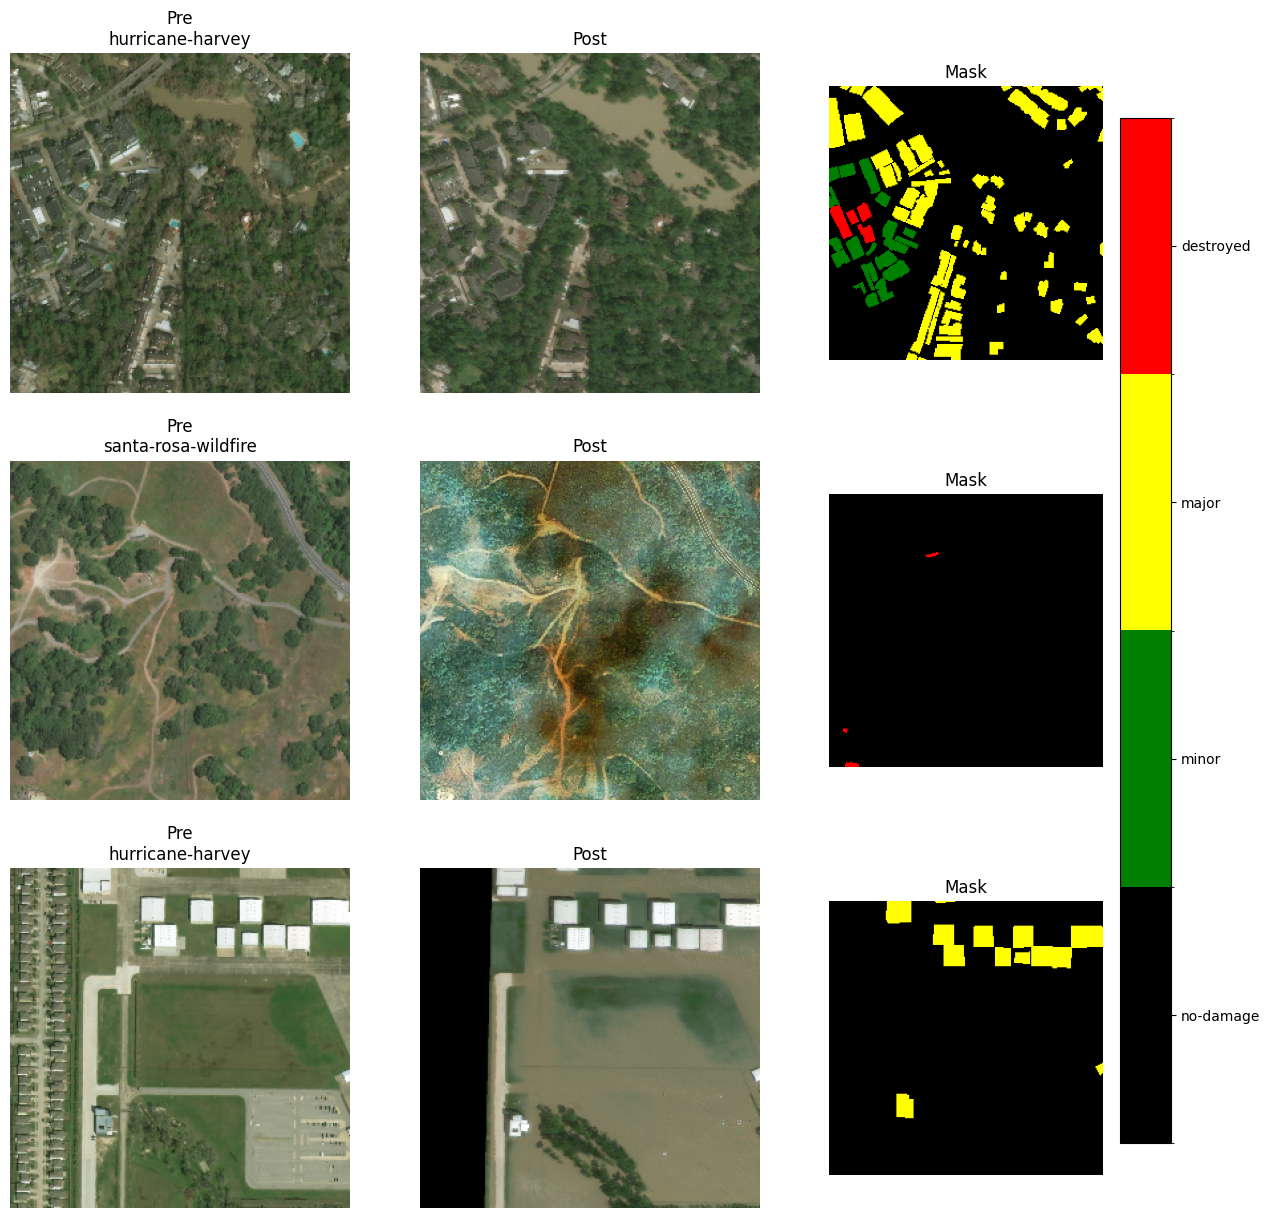

In [7]:
import random

cmap = mcolors.ListedColormap(['black', 'green', 'yellow', 'red'])
bounds = [0, 1, 2, 3, 4]
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# find masks with actual damage
damage_masks = [f for f in all_masks if len(np.unique(cv2.imread(str(f), cv2.IMREAD_GRAYSCALE))) > 1]
samples = random.sample(damage_masks, 3)

fig, axes = plt.subplots(3, 3, figsize=(15, 15))

for i, mask_path in enumerate(samples):
    pre_path  = OUTPUT_DIR / 'train' / 'pre'  / mask_path.name
    post_path = OUTPUT_DIR / 'train' / 'post' / mask_path.name
    
    pre  = cv2.cvtColor(cv2.imread(str(pre_path)),  cv2.COLOR_BGR2RGB)
    post = cv2.cvtColor(cv2.imread(str(post_path)), cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    
    axes[i, 0].imshow(pre)
    axes[i, 0].set_title(f'Pre\n{mask_path.name.split("_")[0]}')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(post)
    axes[i, 1].set_title('Post')
    axes[i, 1].axis('off')
    
    im = axes[i, 2].imshow(mask, cmap=cmap, norm=norm)
    axes[i, 2].set_title('Mask')
    axes[i, 2].axis('off')

plt.colorbar(im, ax=axes[:, 2], ticks=[0.5, 1.5, 2.5, 3.5]).set_ticklabels(['no-damage', 'minor', 'major', 'destroyed'])
plt.show()

In [8]:
mask_path = damage_masks[0]
pre_path  = OUTPUT_DIR / 'train' / 'pre'  / mask_path.name
post_path = OUTPUT_DIR / 'train' / 'post' / mask_path.name

pre  = cv2.imread(str(pre_path))
post = cv2.imread(str(post_path))
mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

print(f"Pre shape:  {pre.shape}")
print(f"Post shape: {post.shape}")
print(f"Mask shape: {mask.shape}")

Pre shape:  (256, 256, 3)
Post shape: (256, 256, 3)
Mask shape: (256, 256)
